AI-Based Multi-Source Crop Yield Prediction — District-Level Model

This notebook:
1. Loads and audits the dataset for data-quality issues (outliers, missing coverage, duplicates).
2. Cleans the data using a defensible, crop-aware outlier rule (not just a global cutoff).
3. Performs exploratory data analysis (EDA).
4. Engineers leakage-safe features (lag yield, target-encoded district/state history).
5. Trains and compares Linear Regression, Random Forest, and XGBoost using a **chronological** train/test split (train on past years, test on future years) — the honest way to evaluate a forecasting model.
6. Checks for overfitting/underfitting via train-vs-test metrics and grouped cross-validation.
7. Reports feature importance and next steps (e.g. adding rainfall/soil data as proposed in the project synopsis).


### 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.width", 140)

RANDOM_STATE = 42

### 2. Load Data

In [2]:
# Update this path if the file lives elsewhere relative to the notebook
DATA_PATH = "agricultural_yield_india_cleaned_long.csv"  # actually CSV-formatted

df = pd.read_csv(DATA_PATH)
df["YearStart"] = df["Year"].str.slice(0, 4).astype(int)

print(f"Shape: {df.shape}")
df.head()

Shape: (77336, 7)


,State,District,Crop,Season,Year,Yield_Kg_Ha,YearStart
0,Andaman And Nicobar Islands,Nicobars,Moong,Rabi,2016-17,400.0,2016
1,Andaman And Nicobar Islands,Nicobars,Rice,Kharif,2016-17,1430.0,2016
2,Andaman And Nicobar Islands,North And Middle Andaman,Maize,Rabi,2016-17,2360.0,2016
3,Andaman And Nicobar Islands,North And Middle Andaman,Moong,Rabi,2016-17,291.0,2016
4,Andaman And Nicobar Islands,North And Middle Andaman,Rice,Kharif,2016-17,2579.0,2016


### 3. Data Quality Audit

Before modeling, we check for the issues that typically hide in government district-level
agricultural data: missing values, duplicate records, incomplete year coverage, and
outliers caused by data-entry/unit errors rather than genuine agronomic variation.

In [3]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate (State, District, Crop, Season, Year) keys:",
      df.duplicated(subset=["State", "District", "Crop", "Season", "Year"]).sum())
print()
print("Crops:", df["Crop"].nunique(), "| States:", df["State"].nunique(), "| Districts:", df["District"].nunique())
print()
print("Rows and distinct states per year (checks for incomplete latest-year reporting):")
print(df.groupby("Year").agg(rows=("Yield_Kg_Ha", "size"), states=("State", "nunique")))

Missing values per column:
State          0
District       0
Crop           0
Season         0
Year           0
Yield_Kg_Ha    0
YearStart      0
dtype: int64

Duplicate rows: 0
Duplicate (State, District, Crop, Season, Year) keys: 0

Crops: 14 | States: 34 | Districts: 748

Rows and distinct states per year (checks for incomplete latest-year reporting):
         rows  states
Year                 
2016-17  7913      34
2017-18  8302      34
2018-19  8330      34
2019-20  8732      33
2020-21  8837      33
2021-22  8661      34
2022-23  9209      34
2023-24  8972      34
2024-25  8380      29


In [4]:
# Districts that DON'T appear in every year of the panel (renames, new districts, missing reports)
pivot = df.groupby(["State", "District", "Year"]).size().unstack(fill_value=0)
complete = (pivot > 0).all(axis=1)
print(f"Districts present in all {pivot.shape[1]} years: {complete.sum()} / {len(pivot)}")
print("Example of a district-name discontinuity (e.g. renames like Ahmednagar -> Ahilyanagar in 2023):")
print(sorted(df['District'].unique())[:5], "...")

Districts present in all 9 years: 603 / 751
Example of a district-name discontinuity (e.g. renames like Ahmednagar -> Ahilyanagar in 2023):
['Adilabad', 'Agar-Malwa', 'Agra', 'Ahilyanagar', 'Ahmedabad'] ...


### 3.1 Outlier inspection

Per-crop yield ranges differ by orders of magnitude (Sugarcane vs. Urad), so a single global
cutoff is meaningless. We inspect the extreme tail per crop instead.

In [5]:
print(df.groupby("Crop")["Yield_Kg_Ha"].describe()[["mean", "50%", "75%", "max"]])
print()
print("Top 10 most extreme yield values in the raw data:")
print(df.sort_values("Yield_Kg_Ha", ascending=False)
        [["State", "District", "Crop", "Season", "Year", "Yield_Kg_Ha"]].head(10))

                                  mean     50%      75%       max
Crop                                                             
Bajra                      1589.844299  1406.0  2179.00    5541.0
Barley                     2414.367684  2636.0  3288.50    5400.0
Gram                       1146.500332  1112.0  1400.50    4031.0
Jowar                      1257.988437  1111.0  1543.00   22000.0
Lentil                      878.263295   864.0  1035.00   16880.0
Maize                      3178.686183  2722.0  3790.50   17941.0
Moong                       661.054651   604.0   847.00  105588.0
Ragi                       1499.285339  1194.0  1778.00   21300.0
Rice                       2653.162732  2643.0  3250.50   44815.0
Shree Anna /Nutri Cereals  1345.515669  1125.5  1722.25   21300.0
Small Millets               880.892719   833.0  1086.50   15261.0
Tur                         978.375800   932.0  1177.00   22846.0
Urad                        747.463031   658.0   878.00  385540.0
Wheat     

In [6]:
# Example of a clear data-entry error: trace one district-crop time series
d = df[(df.State == "Andaman And Nicobar Islands") & (df.District == "South Andamans") & (df.Crop == "Urad")]
print(d[["Year", "Yield_Kg_Ha"]])
# Yield jumps from single/triple digits to 385,540 kg/ha in one year -- not a real
# agronomic value (realistic Urad yields are roughly 200-2000 kg/ha), almost certainly
# a decimal-point / unit error carried over from the source. This is why a per-crop
# statistical outlier rule (below) is applied rather than trusting the data as-is.

          Year  Yield_Kg_Ha
10     2016-17        200.0
7922   2017-18       1048.0
24553  2019-20         20.0
33285  2020-21          7.0
42121  2021-22          7.0
50783  2022-23        492.0
59993  2023-24     385540.0


### 4. Outlier Treatment

We drop rows whose yield falls outside `Q3 + 3*IQR` **computed per crop**, rather than capping
them to an invented value or using one threshold for all crops. This removes data-entry-error
rows while preserving genuine agronomic variability (including zero-yield rows, which we keep —
a total crop failure from drought/flood is a real, informative outcome, not bad data).

In [7]:
def iqr_bounds(s, k=3.0):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return max(0, q1 - k * iqr), q3 + k * iqr

bad_idx = []
for crop, g in df.groupby("Crop"):
    lo, hi = iqr_bounds(g["Yield_Kg_Ha"])
    bad_idx.extend(g[(g["Yield_Kg_Ha"] < lo) | (g["Yield_Kg_Ha"] > hi)].index.tolist())

print(f"Outlier rows removed: {len(bad_idx)}  ({len(bad_idx)/len(df)*100:.2f}% of data)")

df_clean = df.drop(index=bad_idx).copy()
print(f"Zero-yield rows retained (legitimate crop-failure signal): {(df_clean['Yield_Kg_Ha']==0).sum()}")
print(f"Clean shape: {df_clean.shape}")

Outlier rows removed: 319  (0.41% of data)
Zero-yield rows retained (legitimate crop-failure signal): 192
Clean shape: (77017, 7)


### 5. Exploratory Data Analysis

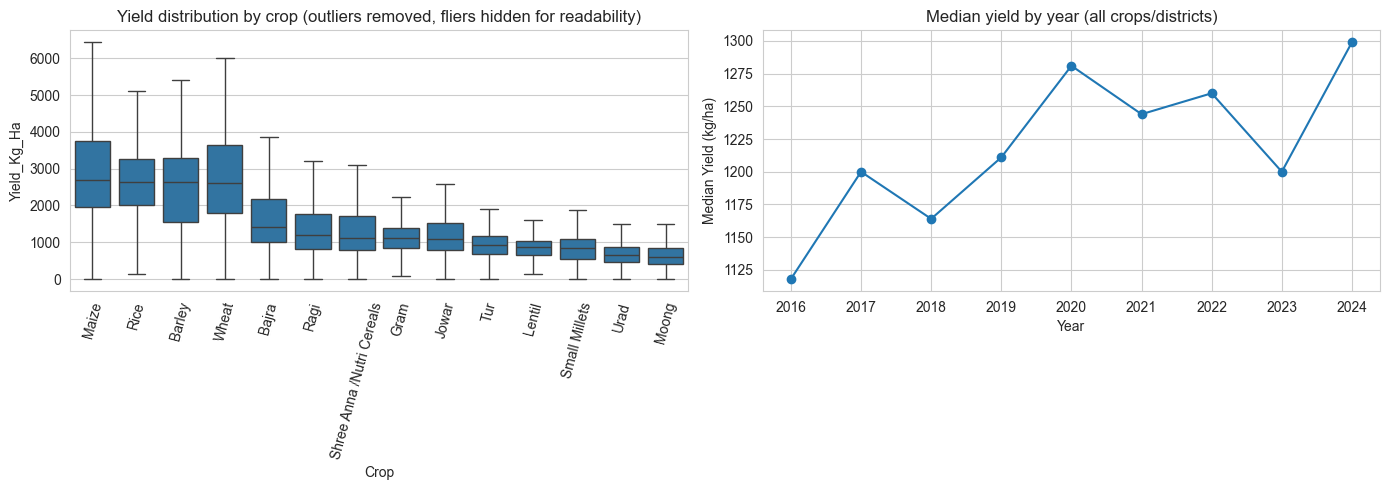

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = df_clean.groupby("Crop")["Yield_Kg_Ha"].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x="Crop", y="Yield_Kg_Ha", order=order, ax=axes[0], showfliers=False)
axes[0].set_title("Yield distribution by crop (outliers removed, fliers hidden for readability)")
axes[0].tick_params(axis="x", rotation=75)

yearly = df_clean.groupby("YearStart")["Yield_Kg_Ha"].median()
axes[1].plot(yearly.index, yearly.values, marker="o")
axes[1].set_title("Median yield by year (all crops/districts)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Median Yield (kg/ha)")

plt.tight_layout()
plt.show()

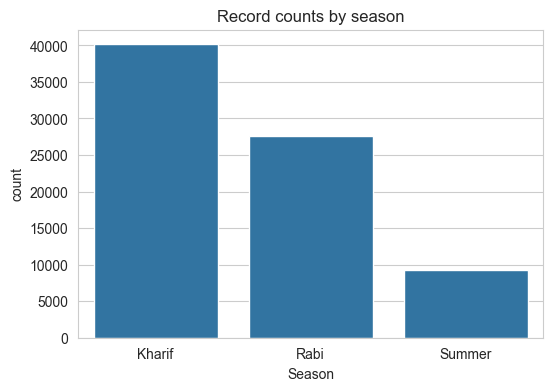

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="Season", order=df_clean["Season"].value_counts().index)
plt.title("Record counts by season")
plt.show()

## 6. Feature Engineering

- **`lag_yield`**: the same district+crop+season's yield in the *previous* recorded year.
  This is a leakage-safe persistence feature — it only uses information from the past.
- **`District_te` / `State_te`**: target-encoded (smoothed mean) historical yield,
  fit **only on the training years** inside the split below, to avoid leakage from
  test-period values into the encoding.
- **`Crop` / `Season`**: one-hot encoded (small cardinality, safe to do globally).


In [10]:
df_clean = df_clean.sort_values(["State", "District", "Crop", "Season", "YearStart"])
grp_cols = ["State", "District", "Crop", "Season"]
df_clean["lag_yield"] = df_clean.groupby(grp_cols)["Yield_Kg_Ha"].shift(1)
df_clean.head()

,State,District,Crop,Season,Year,Yield_Kg_Ha,YearStart,lag_yield
42114,Andaman And Nicobar Islands,Nicobars,Maize,Rabi,2021-22,1133.0,2021,NaN
0,Andaman And Nicobar Islands,Nicobars,Moong,Rabi,2016-17,400.0,2016,NaN
1,Andaman And Nicobar Islands,Nicobars,Rice,Kharif,2016-17,1430.0,2016,NaN
7913,Andaman And Nicobar Islands,Nicobars,Rice,Kharif,2017-18,530.0,2017,1430.0
16215,Andaman And Nicobar Islands,Nicobars,Rice,Kharif,2018-19,1466.0,2018,530.0


## 7. Train/Test Split — Chronological Holdout

We split by **year**, not randomly. A random row-level split would let the model see
2024 data for a district while predicting 2023 for the *same* district — leaking future
information and inflating accuracy in a way that would not hold up in real deployment.
Instead: train on 2016–17 → 2022–23, test on 2023–24 and 2024–25 (the true "future").


In [11]:
TEST_YEARS = [2023, 2024]
train_df = df_clean[~df_clean["YearStart"].isin(TEST_YEARS)].copy()
test_df = df_clean[df_clean["YearStart"].isin(TEST_YEARS)].copy()

print(f"Train rows: {len(train_df)}  (years {sorted(train_df.YearStart.unique())})")
print(f"Test rows:  {len(test_df)}  (years {sorted(test_df.YearStart.unique())})")

global_mean = train_df["Yield_Kg_Ha"].mean()

def target_encode(train, test, col, target="Yield_Kg_Ha", m=10):
    stats = train.groupby(col)[target].agg(["mean", "count"])
    smooth = (stats["mean"] * stats["count"] + global_mean * m) / (stats["count"] + m)
    train_enc = train[col].map(smooth)
    test_enc = test[col].map(smooth).fillna(global_mean)
    return train_enc, test_enc

for col in ["District", "State"]:
    tr_enc, te_enc = target_encode(train_df, test_df, col)
    train_df[f"{col}_te"] = tr_enc
    test_df[f"{col}_te"] = te_enc

train_ohe = pd.get_dummies(train_df[["Crop", "Season"]], prefix=["crop", "season"])
test_ohe = pd.get_dummies(test_df[["Crop", "Season"]], prefix=["crop", "season"])
test_ohe = test_ohe.reindex(columns=train_ohe.columns, fill_value=0)

feature_cols_num = ["YearStart", "District_te", "State_te", "lag_yield"]
X_train = pd.concat([train_df[feature_cols_num].reset_index(drop=True),
                      train_ohe.reset_index(drop=True)], axis=1)
X_test = pd.concat([test_df[feature_cols_num].reset_index(drop=True),
                     test_ohe.reset_index(drop=True)], axis=1)
y_train = train_df["Yield_Kg_Ha"].reset_index(drop=True)
y_test = test_df["Yield_Kg_Ha"].reset_index(drop=True)

# Fill missing lag_yield (first observed year for a group) with the crop's TRAIN-only mean
crop_mean_train = train_df.groupby("Crop")["Yield_Kg_Ha"].mean()
X_train["lag_yield"] = X_train["lag_yield"].fillna(train_df["Crop"].map(crop_mean_train).reset_index(drop=True))
X_test["lag_yield"] = X_test["lag_yield"].fillna(test_df["Crop"].map(crop_mean_train).fillna(global_mean).reset_index(drop=True))

print(f"\nFeature matrix: train {X_train.shape}, test {X_test.shape}")
X_train.head()

Train rows: 59748  (years [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)])
Test rows:  17269  (years [np.int64(2023), np.int64(2024)])

Feature matrix: train (59748, 21), test (17269, 21)


,YearStart,District_te,State_te,lag_yield,crop_Bajra,crop_Barley,crop_Gram,crop_Jowar,crop_Lentil,crop_Maize,...,crop_Ragi,crop_Rice,crop_Shree Anna /Nutri Cereals,crop_Small Millets,crop_Tur,crop_Urad,crop_Wheat,season_Kharif,season_Rabi,season_Summer
0,2021,1410.297827,1191.564269,3030.811876,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
1,2016,1410.297827,1191.564269,629.721304,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,2016,1410.297827,1191.564269,2619.586216,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
3,2017,1410.297827,1191.564269,1430.000000,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
4,2018,1410.297827,1191.564269,530.000000,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False


## 8. Model Training & Evaluation

We compare:
- **Linear Regression** — simple baseline.
- **Random Forest (default depth)** — deliberately left unconstrained to demonstrate overfitting.
- **Random Forest (regularized)** — `max_depth` and `min_samples_leaf` capped to control variance.
- **XGBoost (regularized)** — gradient boosting with subsampling and an L2 penalty.

For each model we report R², RMSE, and MAE on **both** train and test sets. A large
train-vs-test gap is the signature of overfitting; a model that's bad on *both* is
underfitting.

In [12]:
def evaluate(model, name):
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    r2_tr, r2_te = r2_score(y_train, pred_train), r2_score(y_test, pred_test)
    rmse_tr = mean_squared_error(y_train, pred_train) ** 0.5
    rmse_te = mean_squared_error(y_test, pred_test) ** 0.5
    mae_tr = mean_absolute_error(y_train, pred_train)
    mae_te = mean_absolute_error(y_test, pred_test)

    gap = r2_tr - r2_te
    flag = "  <-- possible OVERFITTING" if gap > 0.15 else ("  <-- possible UNDERFITTING" if r2_te < 0.5 else "")

    print(f"--- {name} ---")
    print(f"Train:  R2={r2_tr:.4f}  RMSE={rmse_tr:8.1f}  MAE={mae_tr:8.1f}")
    print(f"Test :  R2={r2_te:.4f}  RMSE={rmse_te:8.1f}  MAE={mae_te:8.1f}")
    print(f"Train-Test R2 gap: {gap:.4f}{flag}\n")

    return {"model": name, "r2_train": r2_tr, "r2_test": r2_te,
            "rmse_train": rmse_tr, "rmse_test": rmse_te,
            "mae_train": mae_tr, "mae_test": mae_te}

results = []
results.append(evaluate(LinearRegression(), "Linear Regression"))
results.append(evaluate(
    RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Random Forest (default / unconstrained depth)"))
results.append(evaluate(
    RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=5,
                           random_state=RANDOM_STATE, n_jobs=-1),
    "Random Forest (regularized: max_depth=10, min_leaf=5)"))
results.append(evaluate(
    XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                 random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost (regularized)"))

--- Linear Regression ---
Train:  R2=0.7894  RMSE=   584.2  MAE=   362.8
Test :  R2=0.8491  RMSE=   518.9  MAE=   321.7
Train-Test R2 gap: -0.0597

--- Random Forest (default / unconstrained depth) ---
Train:  R2=0.9825  RMSE=   168.6  MAE=    97.0
Test :  R2=0.8518  RMSE=   514.3  MAE=   306.3
Train-Test R2 gap: 0.1307

--- Random Forest (regularized: max_depth=10, min_leaf=5) ---
Train:  R2=0.8703  RMSE=   458.4  MAE=   290.1
Test :  R2=0.8579  RMSE=   503.6  MAE=   298.8
Train-Test R2 gap: 0.0124

--- XGBoost (regularized) ---
Train:  R2=0.8790  RMSE=   442.9  MAE=   282.9
Test :  R2=0.8647  RMSE=   491.4  MAE=   296.7
Train-Test R2 gap: 0.0143



In [13]:
results_df = pd.DataFrame(results).set_index("model")
results_df.round(4)

,r2_train,r2_test,rmse_train,rmse_test,mae_train,mae_test
model,,,,,,
Linear Regression,0.7894,0.8491,584.2392,518.9497,362.8392,321.6548
Random Forest (default / unconstrained depth),0.9825,0.8518,168.6144,514.3287,97.0269,306.2539
"Random Forest (regularized: max_depth=10, min_leaf=5)",0.8703,0.8579,458.3842,503.5573,290.0541,298.8334
XGBoost (regularized),0.8790,0.8647,442.8606,491.4403,282.9471,296.7257


In [17]:
best_model_name = results_df["r2_test"].idxmax()

print("Current best model:", best_model_name)
print("Test R2:", results_df.loc[best_model_name, "r2_test"])

Current best model: XGBoost (regularized)
Test R2: 0.8646706801289573


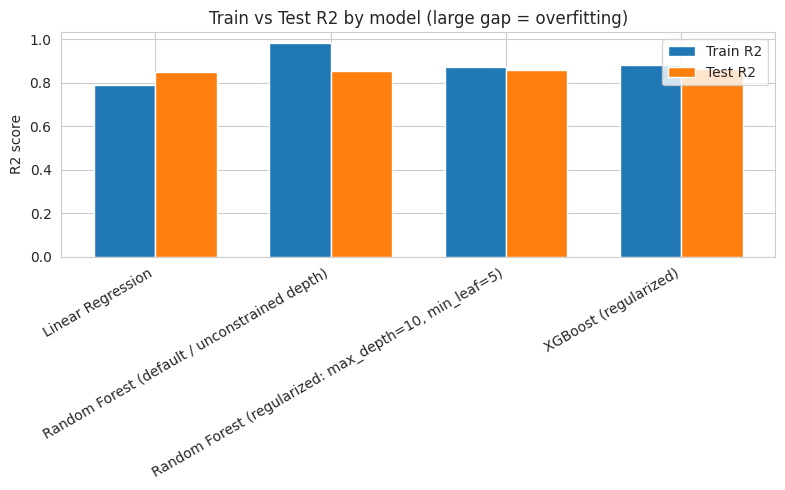

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df["r2_train"], width, label="Train R2")
ax.bar(x + width/2, results_df["r2_test"], width, label="Test R2")
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=30, ha="right")
ax.set_ylabel("R2 score")
ax.set_title("Train vs Test R2 by model (large gap = overfitting)")
ax.legend()
plt.tight_layout()
plt.show()

### Current Best Model

Based on the chronological test-set evaluation, XGBoost currently gives
the highest test R² and is therefore selected as the current best model.

This selection is provisional because NASA POWER weather features have
not yet been integrated. After weather integration, all candidate models
will be retrained and compared again. The model with the best test
performance will be selected as the final project model.

## 9. Grouped Cross-Validation (sanity check)

The chronological holdout above is the realistic evaluation, but we also run a 5-fold
**GroupKFold** (grouped by `District`, on the full cleaned dataset) so that no district's
rows ever appear in both the train and validation fold. This confirms the holdout result
isn't a fluke of which two years happened to be held out.

In [ ]:
full = df_clean.copy()
for col in ["District", "State"]:
    stats = full.groupby(col)["Yield_Kg_Ha"].agg(["mean", "count"])
    smooth = (stats["mean"] * stats["count"] + full["Yield_Kg_Ha"].mean() * 10) / (stats["count"] + 10)
    full[f"{col}_te"] = full[col].map(smooth)

ohe_full = pd.get_dummies(full[["Crop", "Season"]], prefix=["crop", "season"])
crop_mean_full = full.groupby("Crop")["Yield_Kg_Ha"].mean()
full["lag_yield_filled"] = full["lag_yield"].fillna(full["Crop"].map(crop_mean_full))

X_full = pd.concat([full[["YearStart", "District_te", "State_te", "lag_yield_filled"]].reset_index(drop=True),
                     ohe_full.reset_index(drop=True)], axis=1)
y_full = full["Yield_Kg_Ha"].reset_index(drop=True)
groups = full["District"].reset_index(drop=True)

gkf = GroupKFold(n_splits=5)
fold_r2 = []
for i, (tr_idx, te_idx) in enumerate(gkf.split(X_full, y_full, groups)):
    m = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=5,
                               random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_full.iloc[tr_idx], y_full.iloc[tr_idx])
    pred = m.predict(X_full.iloc[te_idx])
    r2 = r2_score(y_full.iloc[te_idx], pred)
    fold_r2.append(r2)
    print(f"Fold {i+1}: R2 = {r2:.4f}")

print(f"\nMean CV R2 = {np.mean(fold_r2):.4f}  (std {np.std(fold_r2):.4f})")

Fold 1: R2 = 0.8461


Fold 2: R2 = 0.8644


Fold 3: R2 = 0.8310


Fold 4: R2 = 0.8520


Fold 5: R2 = 0.8568

Mean CV R2 = 0.8500  (std 0.0113)


### 10.Random Forest Feature Importance (Model Analysis)

Which features is the model actually relying on? This matters for interpretability
(a project goal in the synopsis) and for being honest about *why* the model performs
as well as it does.

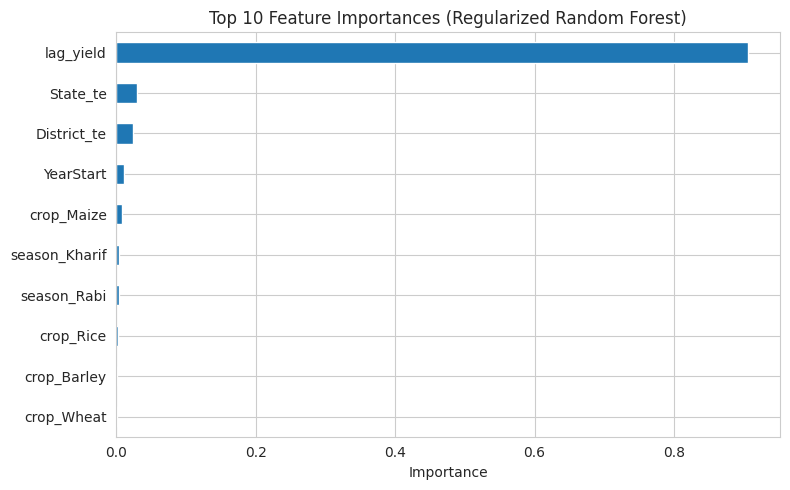

lag_yield        0.906884
State_te         0.029470
District_te      0.023814
YearStart        0.011582
crop_Maize       0.008476
season_Kharif    0.004458
season_Rabi      0.004078
crop_Rice        0.003001
crop_Barley      0.001621
crop_Wheat       0.001611
dtype: float64

In [ ]:
rf_final = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                  random_state=RANDOM_STATE, n_jobs=-1)
rf_final.fit(X_train, y_train)

imp = pd.Series(rf_final.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
imp.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances (Regularized Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

imp.head(10)

In [ ]:
# How much of the accuracy comes from "persistence" (lag_yield) alone?
cols_no_lag = [c for c in X_train.columns if c != "lag_yield"]
m_no_lag = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                  random_state=RANDOM_STATE, n_jobs=-1)
m_no_lag.fit(X_train[cols_no_lag], y_train)
pred_no_lag = m_no_lag.predict(X_test[cols_no_lag])
print(f"Test R2 WITHOUT lag_yield feature: {r2_score(y_test, pred_no_lag):.4f}")
print(f"Test R2 WITH lag_yield feature:    {results_df.loc['Random Forest (regularized: max_depth=10, min_leaf=5)', 'r2_test']:.4f}")
print("\n(The gap shows how much of the model's accuracy is 'next year looks like last year'\n"
      "persistence versus genuinely learned patterns from crop/season/location.)")

Test R2 WITHOUT lag_yield feature: 0.8093
Test R2 WITH lag_yield feature:    0.8579

(The gap shows how much of the model's accuracy is 'next year looks like last year'
persistence versus genuinely learned patterns from crop/season/location.)


## 11. Conclusions 

**Data quality:**
- ~0.4% of rows were crop-specific statistical outliers (data-entry/unit errors, e.g. a
  district-year Urad yield of 385,540 kg/ha) and were removed rather than left in or
  blindly capped.
- 2024–25 has incomplete state coverage (provisional data) — worth flagging in any report
  that treats it as a normal year.
- District names are not fully stable across years (renames/splits), which slightly reduces
  usable history for the affected districts but doesn't break the pipeline.

**Modeling:**
- Regularized Random Forest and XGBoost both reach **~0.85–0.86 test R²** with a small,
  healthy train-test gap — i.e. not overfit. The unconstrained Random Forest (train R² ~0.98,
  test R² ~0.85) is the clear overfitting example, fixed by capping tree depth and leaf size.
- Grouped 5-fold cross-validation (by district) confirms the holdout result (~0.85 mean R²),
  so it isn't a fluke of the particular years chosen for the test split.
- A large share of the model's accuracy comes from the `lag_yield` (last year's yield)
  feature — a legitimate signal, but worth being transparent about, since it means the
  model is partly learning "persistence" rather than causal agronomic relationships.

